<a href="https://colab.research.google.com/github/yahyaMohamadi/MCMC-for-MTEGR/blob/main/MCMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# initiate


In [1]:
from scipy.integrate import quad
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
!pip install getdist
from getdist import MCSamples
from getdist import plots
import matplotlib.pyplot as plt
from IPython.display import clear_output #this is for clearing priat and live plot part to dont have huge amount of output
#np.random.seed(42) #set if you want to reproduce the result
import requests #for conect telegram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 834.0/834.0 kB 13.8 MB/s eta 0:00:00


**MCMC FOR BAOs nad SN la**

# Definition

In [2]:
c = 299792.458  # speed of light in km/s
rd = 147.05      # sound horizon in Mpc

#dimension of curent parameters
dim = 4
parameters_name = ['alpha' ,'beta' ,'Omega_M' ,'H0']
#step_size = np.array([0.01,0.01,0.001,0.001]) #this stepsize is somehow have 30% acceptaion rate on BAO

LCDMparameters = np.array([0,0,0.315,73])

state = {0:"BAO"  ,
         1:"SNe"
         }

#definitions

def H(z , parameters = LCDMparameters):
  alpha, beta, Omega_M, H0 = parameters
  return H0 * ((1 + alpha) / (1 + alpha * (1 + z)**beta)) * np.sqrt(Omega_M * (1 + z)**3 + (1 - Omega_M))

def angular_diameter_distance(z, parameters = LCDMparameters):
  integral, _ = quad(lambda z_: 1 / H(z_, parameters), 0, z)
  return c / (1 + z) * integral

def volume_averaged_distance(z , parameters = LCDMparameters , rd = rd):
  DA = angular_diameter_distance(z, parameters)
  H_z = H(z, parameters)
  return (((1 + z)**2 * c * z / H_z * DA**2)**(1 / 3)) / rd


def luminosity_distance(z, parameters = LCDMparameters):
  return c*(1+z)*quad(lambda z_: 1/H(z_, parameters = parameters),0,z)[0]

def distance_modulus(z , parameters = LCDMparameters):

  return 5*np.log10(luminosity_distance(z , parameters = parameters))+25



#load and save

In [3]:
path_SNe = '/content/drive/MyDrive/chain_SNe_output.csv' #Chain path
path_BAO = '/content/drive/MyDrive/chain_BAO_output.csv'


def load_chain(state,
               parameters_name = parameters_name):
  if  state == "BAO":
    path = path_BAO
  elif state == "SNe":
    path = path_SNe
  data = pd.read_csv(path)
  return data[parameters_name].values.tolist() , data['chi2'].values.tolist()

def save_chain(state , chain_sample , chain_chi2 , parameters_name = parameters_name ):
  if  state == "BAO":
    path = path_BAO
  elif state == "SNe":
    path = path_SNe
  df = pd.DataFrame({**{"chi2": chain_chi2}, **{name: chain_sample[:, i] for i, name in enumerate(parameters_name)}})
  df.to_csv(path, index=False)
  print("Chain saved.")


def get_data_SNe( path = '/content/drive/MyDrive/Pantheon+SH0ES.dat'):
  data = pd.read_csv(path , delim_whitespace=True)
  return np.stack((data['zCMB'].values ,data['MU_SH0ES'].values,data['MU_SH0ES_ERR_DIAG'].values) ,axis=1)


BAO_DESI_DR3 = {
    "BGS":   {"z": 0.295, "DV_over_rd": 7.942,  "error": 0.075},
    "LRG1":  {"z": 0.510, "DV_over_rd": 12.720, "error": 0.099},
    "LRG2":  {"z": 0.706, "DV_over_rd": 16.050, "error": 0.110},
    "LRG3":  {"z": 0.922, "DV_over_rd": 19.656, "error": 0.105},
    "LRG3+ELG1": {"z": 0.934, "DV_over_rd": 19.721, "error": 0.091},
    "ELG1":  {"z": 0.955, "DV_over_rd": 20.008, "error": 0.183},
    "ELG2":  {"z": 1.321, "DV_over_rd": 24.252, "error": 0.174},
    "QSO":   {"z": 1.484, "DV_over_rd": 26.055, "error": 0.398},
    "Lya":   {"z": 2.330, "DV_over_rd": 31.267, "error": 0.256},
}


def get_data_BAO(bao_dict : dict):
  return np.array([[v["z"], v["DV_over_rd"], v["error"]] for v in bao_dict.values()])


data_BAO = get_data_BAO(BAO_DESI_DR3)
data_SNe  = get_data_SNe()




# MCMC

In [4]:

def chi2(data ,state ,parameters = LCDMparameters):
  if state == "SNe":
    z  , observed_distance_modulus ,ERR = data.T
    MTEGR_distance_modulu = np.array([distance_modulus(z = z_ , parameters = parameters) for z_ in z])
    chi2 =  np.sum(((observed_distance_modulus-MTEGR_distance_modulu)/ERR)**2)
  elif state == "BAO":
      z, observed_volume_averaged_distance, ERR = data.T
      MTEGR_volume_averaged_distance = np.array([volume_averaged_distance(z = z_ , parameters = parameters) for z_ in z])
      chi2=  np.sum(((observed_volume_averaged_distance-MTEGR_volume_averaged_distance)/ERR)**2)
  elif state == "BAO+SNe":
      z_BAO, observed_volume_averaged_distance, ERR = data[0].T
      MTEGR_volume_averaged_distance = np.array([volume_averaged_distance(z = z_ , parameters = parameters) for z_ in z_BAO])
      chi2_BAO=  np.sum(((observed_volume_averaged_distance-MTEGR_volume_averaged_distance)/ERR)**2)
      z_SNe  , observed_distance_modulus ,ERR = data[1].T
      MTEGR_distance_modulu = np.array([distance_modulus(z = z_ , parameters = parameters) for z_ in z_SNe])
      chi2_SNe =  np.sum(((observed_distance_modulus-MTEGR_distance_modulu)/ERR)**2)
      chi2 = chi2_BAO/9 + chi2_SNe/1700
  return chi2


def MCMC_step(data ,
              state ,
              sample,
              sample_chi2,
              step_size):
  step_accepted = 0
  proposal_sample = np.random.normal(sample, step_size)
  proposal_chi2 = chi2(data, state,proposal_sample)
  log_accept_prob  = -0.5 * (proposal_chi2- sample_chi2)
  if np.log(np.random.rand()) < log_accept_prob:
    current_sample = proposal_sample
    current_chi2  = proposal_chi2
    step_accepted = 1
  else:
    current_sample = sample
    current_chi2  = sample_chi2
    step_accepted = 0
  return current_sample , current_chi2 , step_accepted



def run_mcmc(data ,
             state,
             n_steps,
             step_size,
             parameters = LCDMparameters,
             report_state = 100,
             continue_fron_old_chian = False ,
             save_while_report =False):


  if continue_fron_old_chian:
      chain_samples , chain_chi2 = load_chain(state)
  else:
    #start chain from LambdaCDM point
    chain_samples = [parameters]
    chain_chi2= [chi2(data ,state, parameters)]
  for i in range(n_steps):
    step = MCMC_step(data,
                     state,
                     sample = chain_samples[-1] ,
                     sample_chi2 = chain_chi2[-1],
                     step_size = step_size)
    chain_samples.append(step[0])
    chain_chi2.append(step[1])
    if (i+2) % report_state == 0:
      live_report(chain_samples,chain_chi2 ,report_state =report_state ,draw_diagram = False)
      curent_acceptation_rate = 0
      repot_tele((i/n_steps)*100)
      if save_while_report:
        save_chain(state, np.array(chain_samples) ,np.array(chain_chi2) ) #make path for save

  return np.array(chain_samples) ,np.array(chain_chi2)

**live Display plot**.
Each report takes approximately 0.72 seconds to process 1,000 steps.

In [5]:
def live_report(chain_samples,
                chain_chi2 ,
                report_state ,
                draw_diagram = False):
    clear_output(wait=True)
    if not draw_diagram:
      print("\n")
      print('step               : ', len(chain_chi2))
      print('acceptation rate % : ', (len(np.unique(chain_chi2[-report_state:]))/report_state)*100)
      print('chi2               : ' , np.average(chain_chi2[-report_state:]))
    if draw_diagram:
      plt_number = 4+2
      samples = list(zip(*chain_samples))
      for i in [1,2,3,4]:
        plt.subplot(plt_number, 1, i)
        plt.plot(samples[i-1], marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
        plt.ylabel(parameters_name[i-1])

      plt.subplot(plt_number, 1, 5)
      plt.plot(chain_chi2, marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
      plt.ylabel("chi")
      plt.subplot(plt_number, 1, 6)

      acceptation_rate = [(len(np.unique(chain_chi2[i:i+report_state])) / report_state)*100 for i in range(0, len(chain_chi2), report_state)]
      plt.plot(acceptation_rate, marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
      plt.ylabel("acc")
      plt.tight_layout()
      plt.show()

try to connect with my tele bot toke is <8470305957:AAFX1TnfuFsBT56SqpRWFExVQy8PSnR8UDQ>  my  id <1039455774>

In [6]:
def repot_tele(progress):
  url = 'https://api.telegram.org/bot8470305957:AAFX1TnfuFsBT56SqpRWFExVQy8PSnR8UDQ/sendMessage?chat_id=1039455774&text=The%20progress%20is%20'+str(int(progress))
  response = requests.get(url)
  return response


In [7]:
#in average for each data point take 1.6 min for one million step
#each 10^6 steps take about 30 megabyte size
mcmc = run_mcmc(data=data_BAO ,
                state="BAO",
                n_steps=6*1000*1000,
                step_size=np.array([0,0.,0.01,0.1]),
                parameters = np.array([ 0   ,  0   ,  0.3, 70.   ]),
                report_state = 50000,
                continue_fron_old_chian = False ,
                save_while_report =False)



step               :  6000000
acceptation rate % :  34.342
chi2               :  7.446438322343356


# autocorrelation

In [ ]:
def autocorrelation(chain, lag):
  autocorrelation = []
  n = len(chain)
  mean = np.mean(chain)
  var = np.var(chain)
  for i in range(lag):
    cov = np.sum((chain[:n-i] - mean) * (chain[i:] - mean)) / (n - i)
    autocorrelation.append(cov / var)
  return np.array(autocorrelation)

/tmp/ipython-input-1273192215.py:8: RuntimeWarning: invalid value encountered in scalar divide
  autocorrelation.append(cov / var)


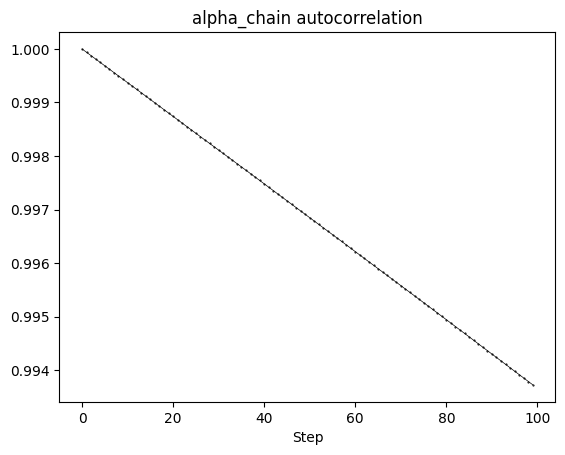

In [ ]:
burn_in =1000
alpha_chain = mcmc[0][burn_in:,0]
beta_chain = mcmc[0][burn_in:,1]
Omega_M_chain = mcmc[0][burn_in:,2]
H0_chain = mcmc[0][burn_in:,3]

lag = 100

alpha_autocorrelation = autocorrelation(chain=alpha_chain, lag=lag)
beta_autocorrelation = autocorrelation(chain=beta_chain, lag=lag)
Omega_M_autocorrelation = autocorrelation(chain=Omega_M_chain, lag=lag)
H0_autocorrelation = autocorrelation(chain=H0_chain, lag=lag)


plt.plot(alpha_autocorrelation , marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
plt.title("alpha_chain autocorrelation")
plt.xlabel("Step")
plt.show()

# Plot and Output

In [ ]:
#load chain from drive if its exist
chain_SNe  , chi2_SNe = np.array(load_chain("SNe")[0]) , np.array(load_chain("SNe")[1])
chain_BAO  , chi2_BAO = np.array(load_chain("BAO")[0]) , np.array(load_chain("BAO")[1])
#chain_BAO_SNe = np.array(chain_BAO_SNe)

In [8]:
#chain from runtime
chain_SNe  , chi2_SNe = mcmc[0] , mcmc[1]
chain_BAO  , chi2_BAO = mcmc[0] , mcmc[1]
#chain_BAO_SNe = np.array(chain_BAO_SNe)

In [9]:
def main_chain_report(chain_samples ,chain_chi2):
  print("best point: " , chain_samples[np.argmin(chain_chi2)] , np.min(chain_chi2))
  print("total acceptation rate: " , len(np.unique(chain_chi2))/len(chain_chi2)*100)
  print("mean of chain" , np.mean(chain_samples,axis=0))
  print("error" , np.std(chain_samples,axis=0))
#main_chain_report(chain_SNe,chi2_SNe)
main_chain_report(chain_BAO,chi2_BAO)

best point:  [ 0.          0.          0.29778513 68.97152697] 5.400333691488782
total acceptation rate:  34.6659942223343
mean of chain [ 0.          0.          0.29853069 68.94590677]
error [0.         0.         0.01238527 0.64095082]


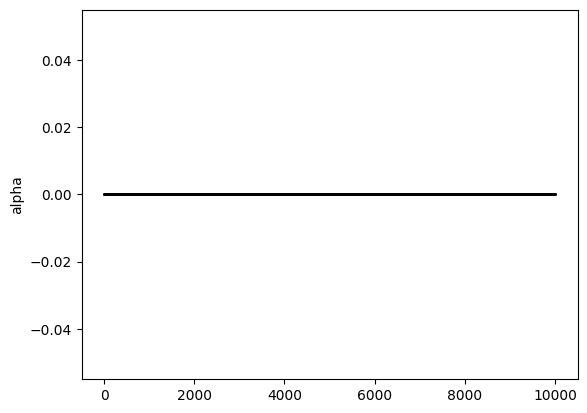

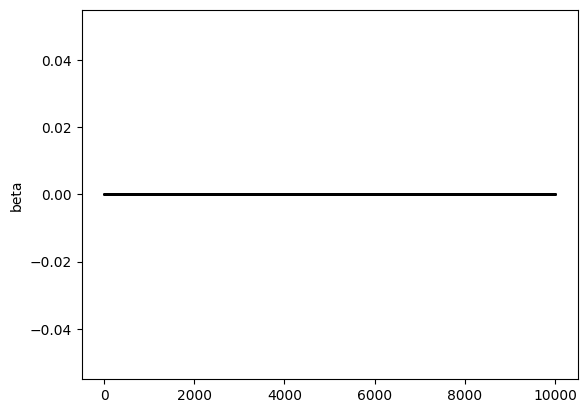

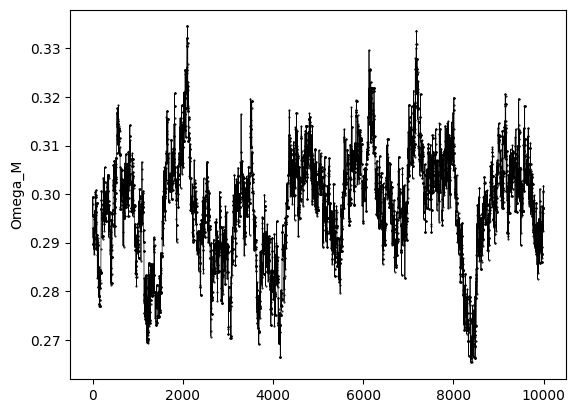

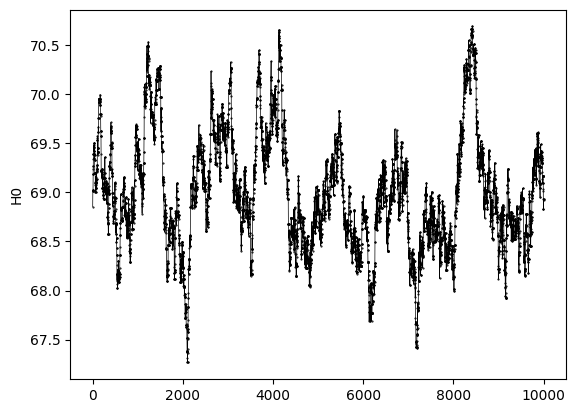

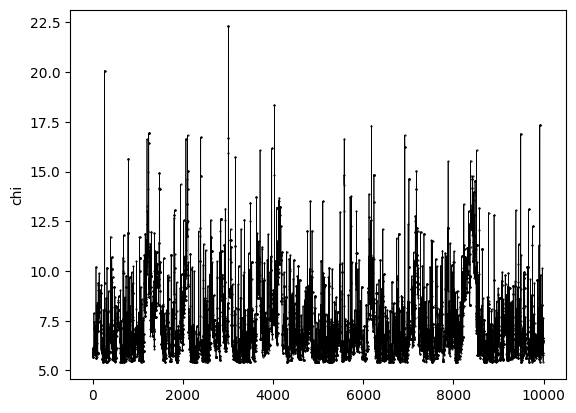

In [15]:
def chain_visual(chain_samples,
                chain_chi2 ):
      samples = chain_samples.T
      for i in range(len(parameters_name)):
        plt.plot(samples[i], marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
        plt.ylabel(parameters_name[i])
        plt.show()
      plt.plot(chain_chi2, marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
      plt.ylabel("chi")
      plt.show()

chain_visual(chain_BAO,
                chi2_BAO)

In [11]:
burn_in = 100000
samples = chain_BAO[burn_in:]
parameter_labels=[r'\alpha', r'\beta' ,  r'\Omega_m','H_0']
samples_obj = MCSamples(samples=samples,
                        names = parameters_name,
                        labels =parameter_labels)

Removed no burn in


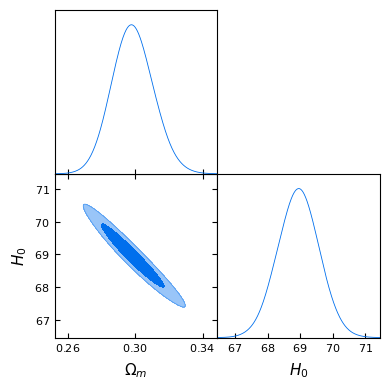

In [12]:
g = plots.get_subplot_plotter()
g.triangle_plot(samples_obj, filled=True)
plt.savefig("triangle_plot.png")
plt.show()

In [ ]:
#triangle plot for  joint data
g = plots.get_subplot_plotter()
g.triangle_plot([samples1, samples2,samples3],
                filled=True,
                legend_labels=["SNe", "BAO" , "SNe+BAO"],
                contour_colors=['blue', 'red',"green"])

plt.savefig("triangle_plot.png")

Removed no burn in
Removed no burn in
Removed no burn in


# Tuning and Running
* this part is prototype, necessitating the development of a robust theoretical framework for effective optimization



In [ ]:
MCMC = run_mcmc(data_BAO,
                state = "BAO",
                parameters=LCDMparameters ,
                step_size = np.array([0.01,0.1,0,0]),
                n_steps=300000,
                report_state= 1000,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainFirst = MCMC[0]

for BAO

In [ ]:
MCMC = run_mcmc(data_BAO,
                state = "BAO",
                parameters=LCDMparameters ,
                step_size = np.array([0,0,0.1,0.1]),
                n_steps=30000,
                report_state= 10000,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainFirst = MCMC[0]

<ipython-input-50-5ec5cace9e14>:18: RuntimeWarning: invalid value encountered in sqrt
  return H0 * ((1 + alpha) / (1 + alpha * (1 + z)**beta)) * np.sqrt(Omega_M * (1 + z)**3 + (1 - Omega_M))
<ipython-input-50-5ec5cace9e14>:21: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(lambda z_: 1 / H(z_, parameters), 0, z)


MCMC curent step is  1020004  curent acceptation rate is  4 % chi2 is  8
Chain saved.
MCMC curent step is  1030004  curent acceptation rate is  3 % chi2 is  10
Chain saved.
MCMC curent step is  1040004  curent acceptation rate is  3 % chi2 is  6
Chain saved.


In [ ]:
MCMC = run_mcmc(data_BAO,
                state = "BAO",
                parameters=LCDMparameters ,
                step_size = np.array([0,0,0.1,0.1]),
                n_steps=3000,
                report_state= 1000,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainFirst = MCMC[0]


MCMC = run_mcmc(data_BAO,
                state = "BAO",
                parameters=np.mean(chainFirst,axis=0) ,
                step_size = np.std(chainFirst,axis=0),
                n_steps=2000,
                report_state= 1000,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainFirst = MCMC[0]

MCMC = run_mcmc(data_BAO,
                state = "BAO",
                parameters= np.mean(chainFirst , axis = 0),
                step_size = np.array([0.1,0.1,0,0]),
                n_steps=3000,
                report_state= 1000,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainSecond = MCMC[0]


MCMC = run_mcmc(data_BAO,
                state = "BAO",
                parameters=np.mean(chainSecond,axis=0) ,
                step_size = np.std(chainSecond,axis=0),
                n_steps=2000,
                report_state= 1000,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainSecond = MCMC[0]

tuned_parameters = np.mean(chainSecond,axis=0)
tuned_step = np.concatenate((np.std(chainSecond,axis=0)[:2], np.std(chainFirst,axis=0)[2:4]))

<ipython-input-50-5ec5cace9e14>:18: RuntimeWarning: invalid value encountered in sqrt
  return H0 * ((1 + alpha) / (1 + alpha * (1 + z)**beta)) * np.sqrt(Omega_M * (1 + z)**3 + (1 - Omega_M))
<ipython-input-50-5ec5cace9e14>:21: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(lambda z_: 1 / H(z_, parameters), 0, z)


MCMC curent step is  1001  curent acceptation rate is  3 % chi2 is  30
MCMC curent step is  2001  curent acceptation rate is  3 % chi2 is  18
MCMC curent step is  3001  curent acceptation rate is  3 % chi2 is  10
MCMC curent step is  1001  curent acceptation rate is  13 % chi2 is  6
MCMC curent step is  2001  curent acceptation rate is  14 % chi2 is  5
MCMC curent step is  1001  curent acceptation rate is  20 % chi2 is  5
MCMC curent step is  2001  curent acceptation rate is  24 % chi2 is  6
MCMC curent step is  3001  curent acceptation rate is  21 % chi2 is  8


<ipython-input-50-5ec5cace9e14>:27: RuntimeWarning: invalid value encountered in scalar power
  return (((1 + z)**2 * c * z / H_z * DA**2)**(1 / 3)) / rd


MCMC curent step is  1001  curent acceptation rate is  5 % chi2 is  5
MCMC curent step is  2001  curent acceptation rate is  6 % chi2 is  5


In [ ]:
print(tuned_parameters)
print(tuned_step)

[ 0.35209334 -0.09995386  0.29811993 68.98795532]
[0.7400635  0.35300526 0.01227906 0.6396733 ]


In [ ]:
MCMC = run_mcmc(data_BAO,
                state = "BAO",
                parameters=tuned_parameters ,
                step_size = tuned_step/6,
                n_steps=10*100*1000,
                report_state= 10000,
                continue_fron_old_chian = False ,
                save_while_report =True)

chain_BAO ,chain_chi2_BAO= MCMC

print(np.mean(chain_BAO,axis=0))
print(np.std(chain_BAO,axis=0))

MCMC curent step is  10001  curent acceptation rate is  21 % chi2 is  10
MCMC curent step is  20001  curent acceptation rate is  15 % chi2 is  7


<ipython-input-50-5ec5cace9e14>:27: RuntimeWarning: invalid value encountered in scalar power
  return (((1 + z)**2 * c * z / H_z * DA**2)**(1 / 3)) / rd


MCMC curent step is  30001  curent acceptation rate is  15 % chi2 is  7
MCMC curent step is  40001  curent acceptation rate is  20 % chi2 is  14
MCMC curent step is  50001  curent acceptation rate is  19 % chi2 is  7
MCMC curent step is  60001  curent acceptation rate is  16 % chi2 is  5
MCMC curent step is  70001  curent acceptation rate is  15 % chi2 is  5
MCMC curent step is  80001  curent acceptation rate is  15 % chi2 is  5
MCMC curent step is  90001  curent acceptation rate is  16 % chi2 is  5
MCMC curent step is  100001  curent acceptation rate is  12 % chi2 is  5
MCMC curent step is  110001  curent acceptation rate is  11 % chi2 is  13
MCMC curent step is  120001  curent acceptation rate is  11 % chi2 is  10
MCMC curent step is  130001  curent acceptation rate is  11 % chi2 is  6
MCMC curent step is  140001  curent acceptation rate is  10 % chi2 is  11
MCMC curent step is  150001  curent acceptation rate is  10 % chi2 is  6
MCMC curent step is  160001  curent acceptation rate i

for SNe

In [ ]:
MCMC = run_mcmc(data_SNe,
                state = "SNe",
                parameters=LCDMparameters ,
                step_size = np.array([0,0,0.1,0.1]),
                n_steps=300,
                report_state= 100,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainFirst = MCMC[0]


MCMC = run_mcmc(data_SNe,
                state = "SNe",
                parameters=np.mean(chainFirst,axis=0) ,
                step_size = np.std(chainFirst,axis=0),
                n_steps=200,
                report_state= 100,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainFirst = MCMC[0]

MCMC = run_mcmc(data_SNe,
                state = "SNe",
                parameters= np.mean(chainFirst , axis = 0),
                step_size = np.array([0.1,0.1,0,0]),
                n_steps=300,
                report_state= 100,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainSecond = MCMC[0]


MCMC = run_mcmc(data_SNe,
                state = "SNe",
                parameters=np.mean(chainSecond,axis=0) ,
                step_size = np.std(chainSecond,axis=0),
                n_steps=200,
                report_state= 100,
                continue_fron_old_chian = False ,
                save_while_report =False)
chainSecond = MCMC[0]

tuned_parameters = np.mean(chainSecond,axis=0)
tuned_step = np.concatenate((np.std(chainSecond,axis=0)[:2], np.std(chainFirst,axis=0)[2:4]))

MCMC curent step is  101  curent acceptation rate is  16 % chi2 is  813
MCMC curent step is  201  curent acceptation rate is  17 % chi2 is  813
MCMC curent step is  301  curent acceptation rate is  16 % chi2 is  813
MCMC curent step is  101  curent acceptation rate is  49 % chi2 is  814
MCMC curent step is  201  curent acceptation rate is  50 % chi2 is  812
MCMC curent step is  101  curent acceptation rate is  68 % chi2 is  812
MCMC curent step is  201  curent acceptation rate is  65 % chi2 is  813
MCMC curent step is  301  curent acceptation rate is  69 % chi2 is  814
MCMC curent step is  101  curent acceptation rate is  54 % chi2 is  814


<ipython-input-50-5ec5cace9e14>:35: RuntimeWarning: invalid value encountered in log10
  return 5*np.log10(luminosity_distance(z , parameters = parameters))+25


MCMC curent step is  201  curent acceptation rate is  34 % chi2 is  813


In [ ]:
MCMC = run_mcmc(data_SNe,
                state = "SNe",
                parameters=tuned_parameters ,
                step_size = tuned_step/10,
                n_steps=10*1000,
                report_state= 100,
                continue_fron_old_chian = False ,
                save_while_report =True)

chain_SNe , chain_chi2_SNe = MCMC


print(np.mean(chain_SNe,axis=0))
print(np.std(chain_SNe,axis=0))

MCMC curent step is  101  curent acceptation rate is  92 % chi2 is  813
Chain saved.
MCMC curent step is  201  curent acceptation rate is  90 % chi2 is  818
Chain saved.
MCMC curent step is  301  curent acceptation rate is  79 % chi2 is  821
Chain saved.
MCMC curent step is  401  curent acceptation rate is  77 % chi2 is  817
Chain saved.
MCMC curent step is  501  curent acceptation rate is  91 % chi2 is  815
Chain saved.
MCMC curent step is  601  curent acceptation rate is  96 % chi2 is  812
Chain saved.
MCMC curent step is  701  curent acceptation rate is  83 % chi2 is  814
Chain saved.
MCMC curent step is  801  curent acceptation rate is  82 % chi2 is  812
Chain saved.
MCMC curent step is  901  curent acceptation rate is  92 % chi2 is  814
Chain saved.
MCMC curent step is  1001  curent acceptation rate is  73 % chi2 is  814
Chain saved.
MCMC curent step is  1101  curent acceptation rate is  80 % chi2 is  818
Chain saved.
MCMC curent step is  1201  curent acceptation rate is  87 % chi

KeyboardInterrupt: 

for SNe+BAO

In [ ]:
MCMC = run_mcmc((data_BAO,data_SNe),
                state = "BAO+SNe",
                parameters=tuned_parameters ,
                step_size = tuned_step/6,
                n_steps=1*1000,
                report_state= 100,
                continue_fron_old_chian = False ,
                save_while_report =False)

chain_BAO_SNe , chain_chi2_BAO_SNe = MCMC

MCMC curent step is  101  curent acceptation rate is  36 % chi2 is  4
MCMC curent step is  201  curent acceptation rate is  33 % chi2 is  3
MCMC curent step is  301  curent acceptation rate is  44 % chi2 is  4
MCMC curent step is  401  curent acceptation rate is  36 % chi2 is  4
MCMC curent step is  501  curent acceptation rate is  33 % chi2 is  4
MCMC curent step is  601  curent acceptation rate is  44 % chi2 is  4
MCMC curent step is  701  curent acceptation rate is  31 % chi2 is  3
MCMC curent step is  801  curent acceptation rate is  36 % chi2 is  4
MCMC curent step is  901  curent acceptation rate is  34 % chi2 is  5
MCMC curent step is  1001  curent acceptation rate is  28 % chi2 is  5
